In [1]:
import os
from config import BLS_START_YEAR, BLS_END_YEAR, RESULTS_DIR
from load import get_unemployment_data, get_functional_trends, get_recreational_trends
from load import plot_unemployment_trends, plot_trends_comparison, plot_average_trends
from process import process_unemployment_records, build_merged_df, run_correlation_analysis

BLS_API_KEY = os.environ.get("BLS_API_KEY")

In [2]:
records = get_unemployment_data(BLS_API_KEY, BLS_START_YEAR, BLS_END_YEAR)
print(f"Fetched {len(records)} records total.")
print(f"Sample record: {records[0]}")

Fetching BLS data 2019-2021...
Fetching BLS data 2022-2024...
Fetched 3600 records total.
Sample record: {'state': 'Alabama', 'year': 2021, 'month': 12, 'unemployment_rate': 2.4}


In [3]:
df, top10_states = process_unemployment_records(records)
print(f"Top 10 states: {top10_states}")

Top 10 states by average unemployment rate:
  1. Nevada 6.74%
  2. California 5.98%
  3. Alaska 5.59%
  4. Illinois 5.58%
  5. New York 5.55%
  6. Michigan 5.43%
  7. New Jersey 5.42%
  8. New Mexico 5.32%
  9. Washington 5.15%
  10. Pennsylvania 5.12%
Top 10 states: ['Nevada', 'California', 'Alaska', 'Illinois', 'New York', 'Michigan', 'New Jersey', 'New Mexico', 'Washington', 'Pennsylvania']


In [4]:
functional_records = get_functional_trends(top10_states)
print(f"Fetched {len(functional_records)} functional trend records.")


Fetching Functional Trends (LinkedIn, Job, Hiring)...
Fetching functional trends for Nevada...
Waiting 4.3s...
Fetching functional trends for California...
Waiting 5.5s...
Fetching functional trends for Alaska...
Waiting 7.3s...
Fetching functional trends for Illinois...
Waiting 4.0s...
Fetching functional trends for New York...
Waiting 4.6s...
Fetching functional trends for Michigan...
Waiting 6.0s...
Fetching functional trends for New Jersey...
Waiting 6.0s...
Fetching functional trends for New Mexico...
Waiting 6.6s...
Fetching functional trends for Washington...
Waiting 5.3s...
Fetching functional trends for Pennsylvania...
Waiting 4.7s...
Fetched 2160 functional trend records.


In [5]:
recreational_records = get_recreational_trends(top10_states)
print(f"Fetched {len(recreational_records)} recreational trend records.")


Fetching Recreational Trends (TikTok, Netflix, Instagram)...
Fetching recreational trends for Nevada...
Waiting 6.4s...
Fetching recreational trends for California...
Waiting 4.3s...
Fetching recreational trends for Alaska...
Waiting 7.1s...
Fetching recreational trends for Illinois...
Waiting 7.8s...
Fetching recreational trends for New York...
Waiting 5.9s...
Fetching recreational trends for Michigan...
Waiting 6.0s...
Fetching recreational trends for New Jersey...
Waiting 5.8s...
Fetching recreational trends for New Mexico...
Waiting 6.9s...
Fetching recreational trends for Washington...
Rate limited! Waiting 60s before retrying Washington...
Fetching recreational trends for Pennsylvania...
Waiting 7.6s...
Fetched 2160 recreational trend records.


In [6]:
merged_df = build_merged_df(records, functional_records, recreational_records, top10_states)
corr_df = run_correlation_analysis(merged_df)
print("\nCorrelation results table:")
print(corr_df.to_string(index=False))


Pearson Correlation Analysis
  Alaska: Functional r=-0.424 (significant), Recreational r=0.572 (significant)
  California: Functional r=-0.494 (significant), Recreational r=0.644 (significant)
  Illinois: Functional r=-0.371 (significant), Recreational r=0.635 (significant)
  Michigan: Functional r=-0.337 (significant), Recreational r=0.585 (significant)
  Nevada: Functional r=-0.310 (significant), Recreational r=0.669 (significant)
  New Jersey: Functional r=-0.372 (significant), Recreational r=0.676 (significant)
  New Mexico: Functional r=-0.275 (significant), Recreational r=0.718 (significant)
  New York: Functional r=-0.576 (significant), Recreational r=0.676 (significant)
  Pennsylvania: Functional r=-0.434 (significant), Recreational r=0.737 (significant)
  Washington: Functional r=-0.371 (significant), Recreational r=0.693 (significant)

Avg Functional correlation: r=-0.396
Avg Recreational correlation: r=0.661

Correlation results table:
       state  func_corr  func_pvalue  

Saved: unemployment_trends.png


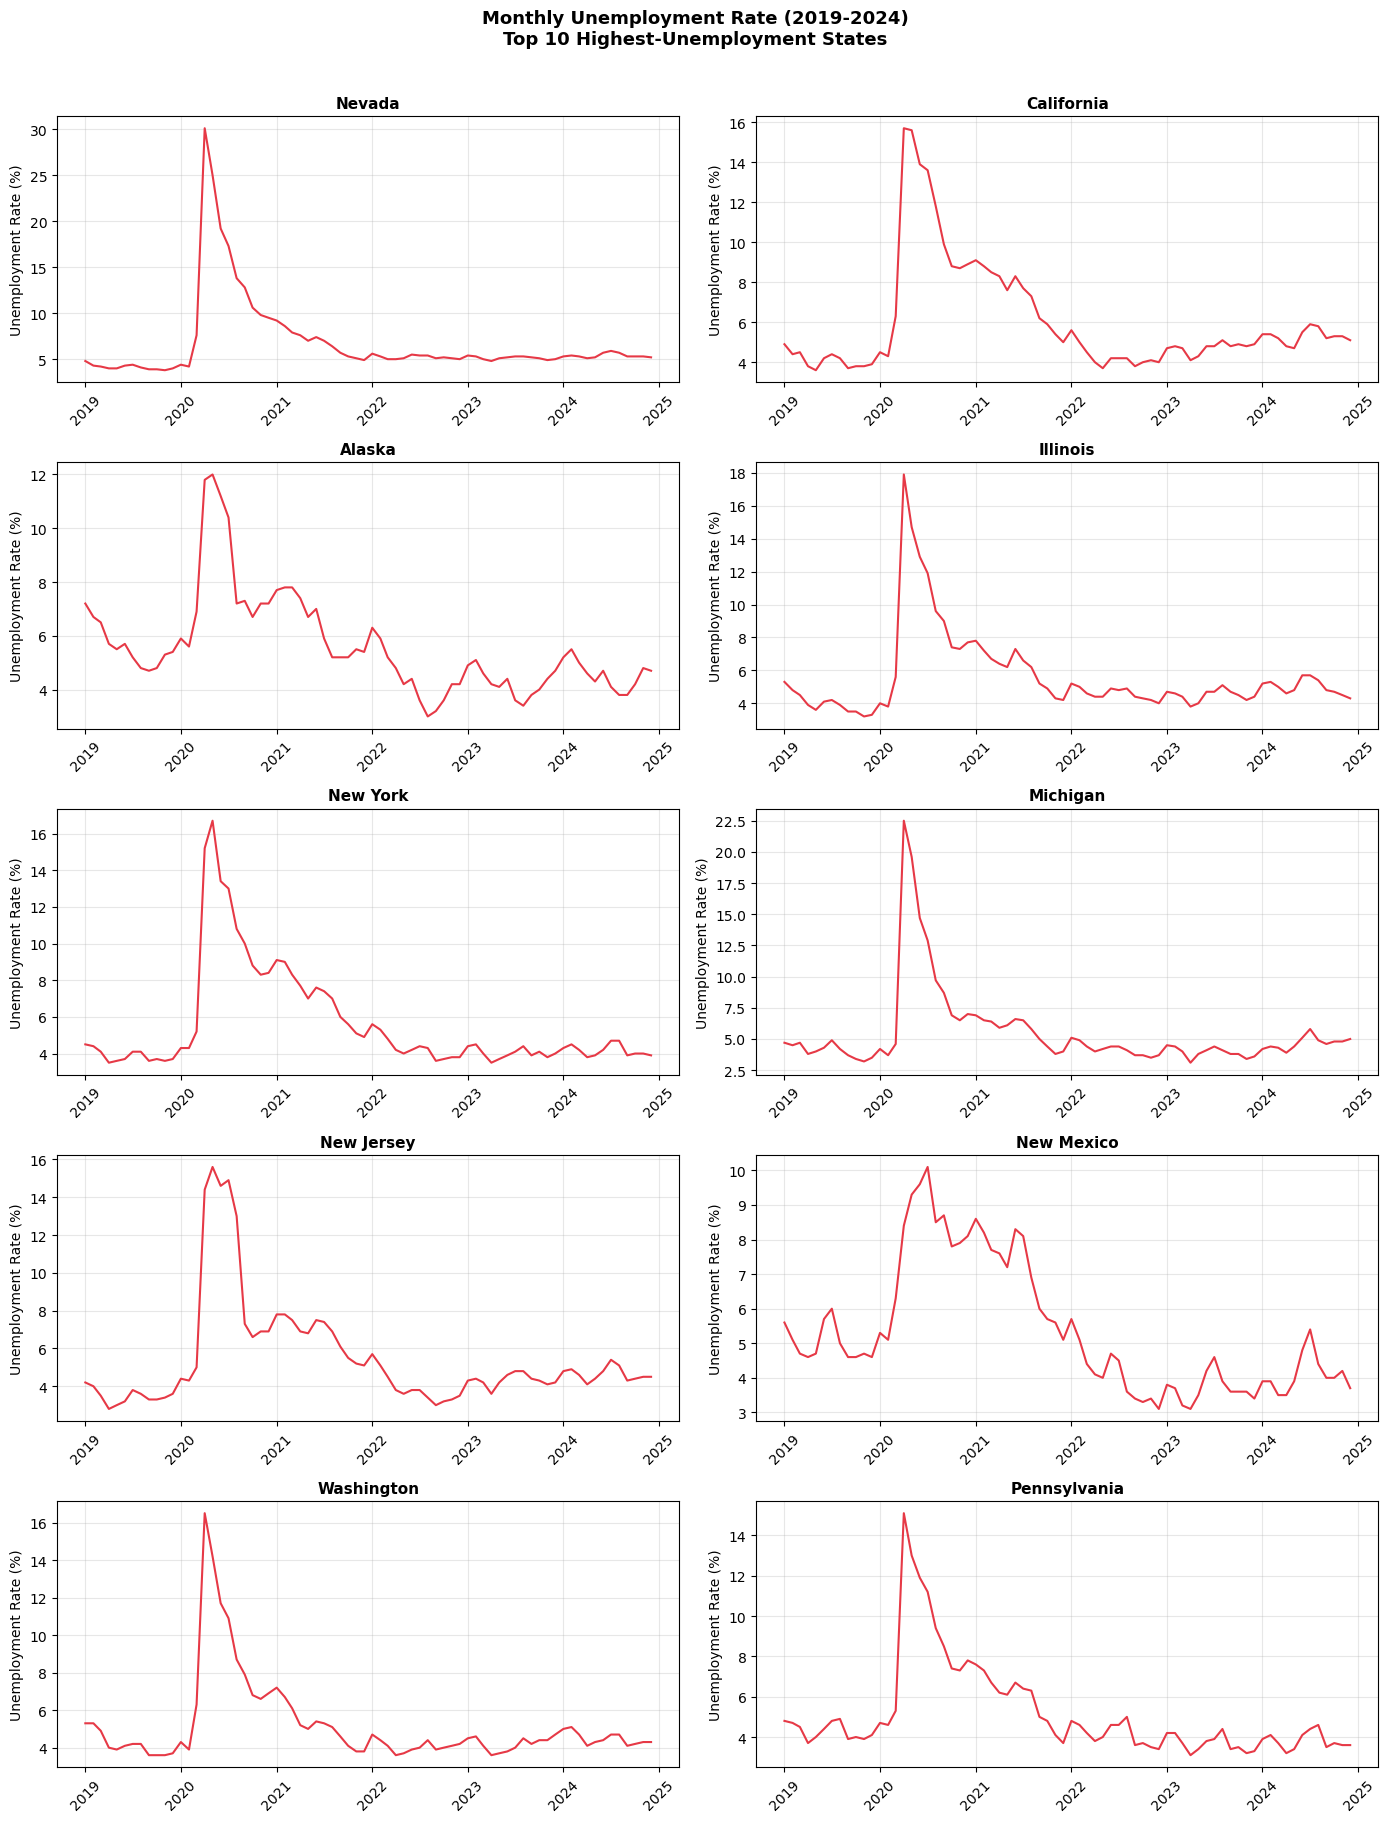

In [7]:
os.makedirs(RESULTS_DIR, exist_ok=True)
plot_unemployment_trends(records, top10_states, result_dir=RESULTS_DIR)

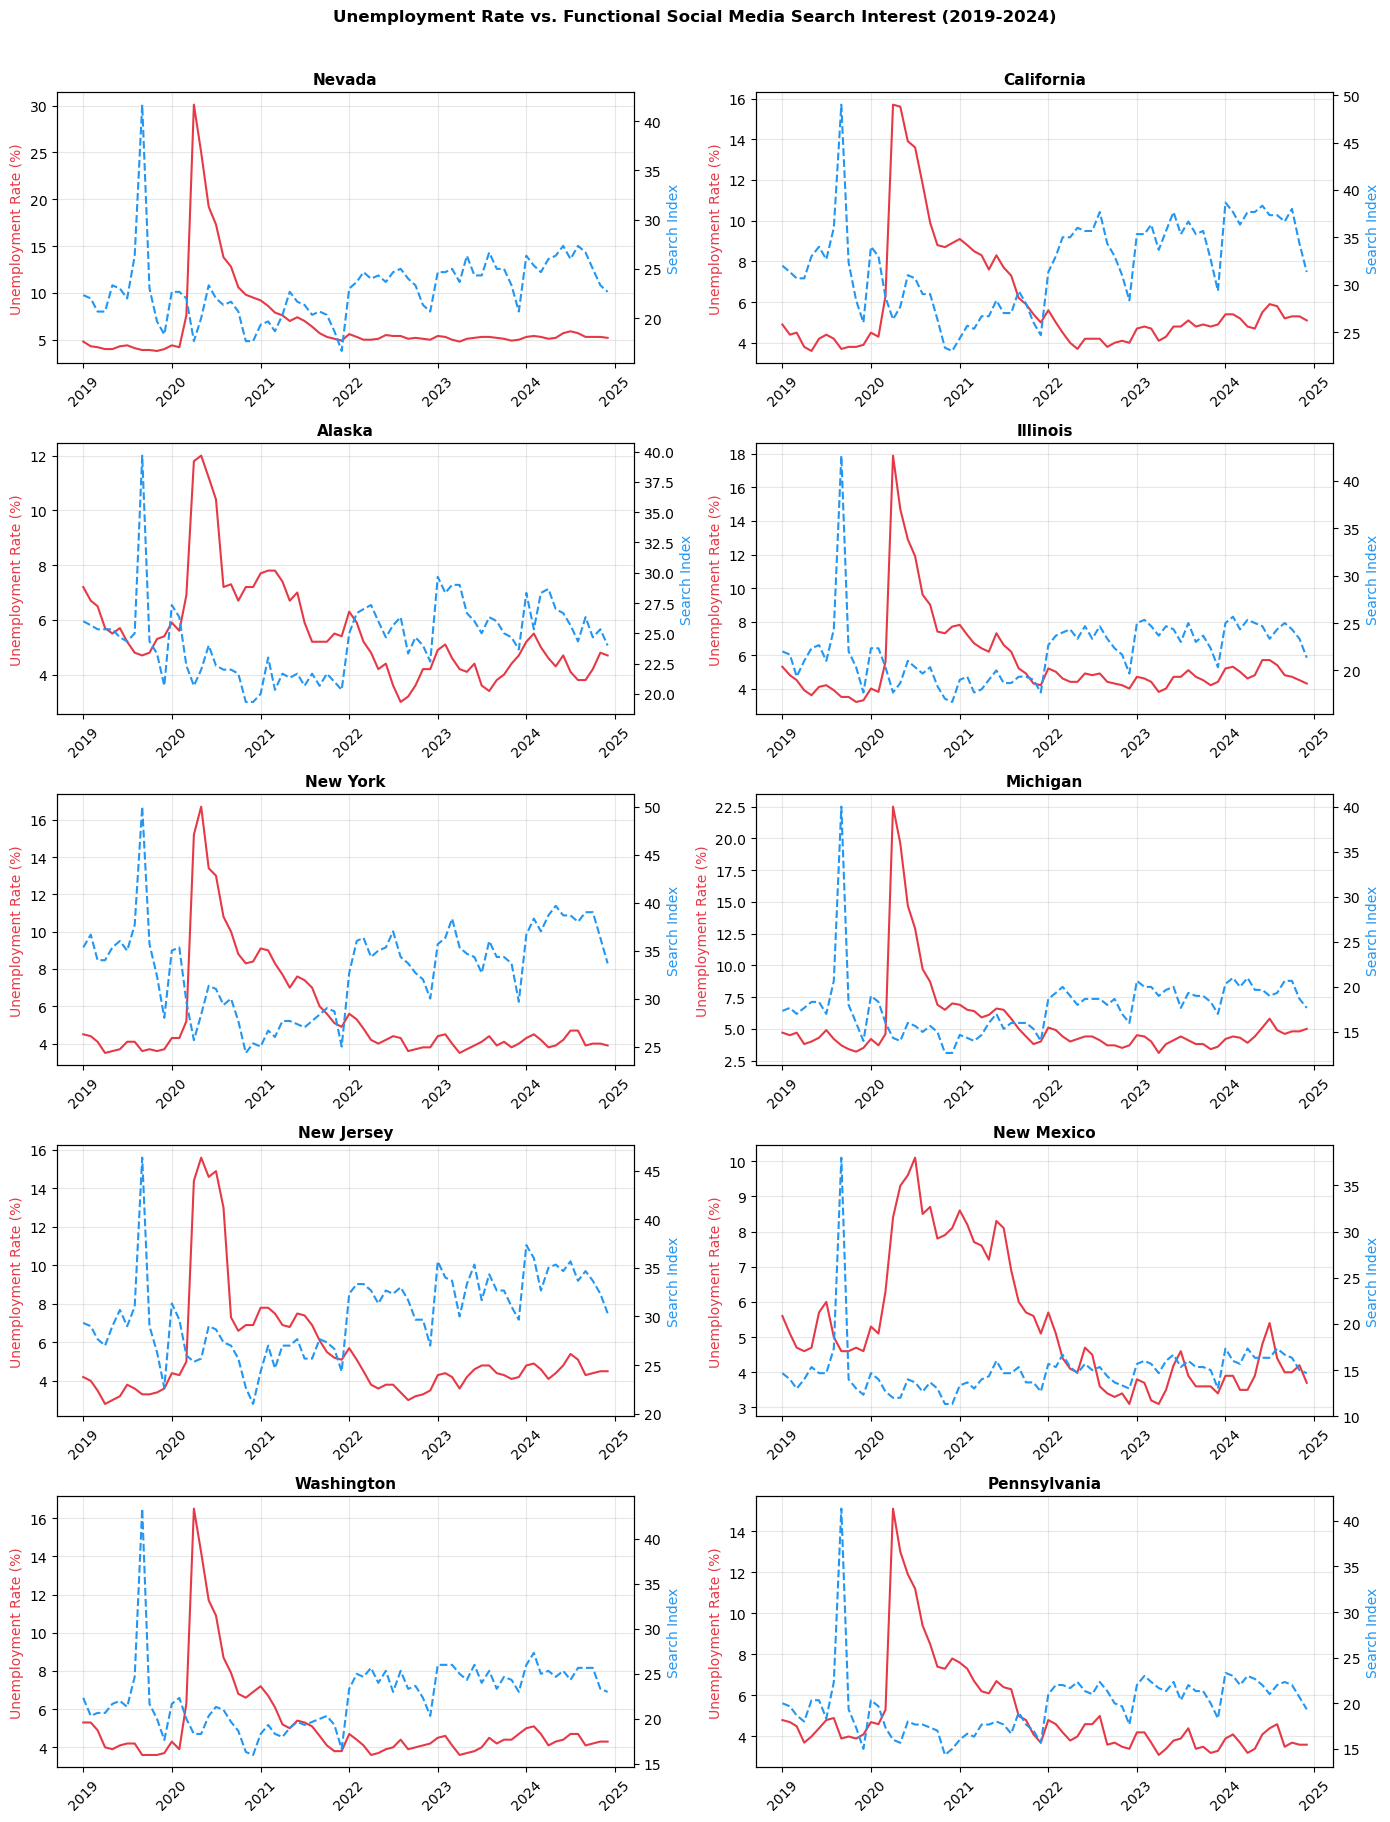

Saved: functional_trends_comparison.png


In [8]:
if functional_records:
    plot_trends_comparison(records, functional_records, top10_states,
                           category="functional", result_dir=RESULTS_DIR)

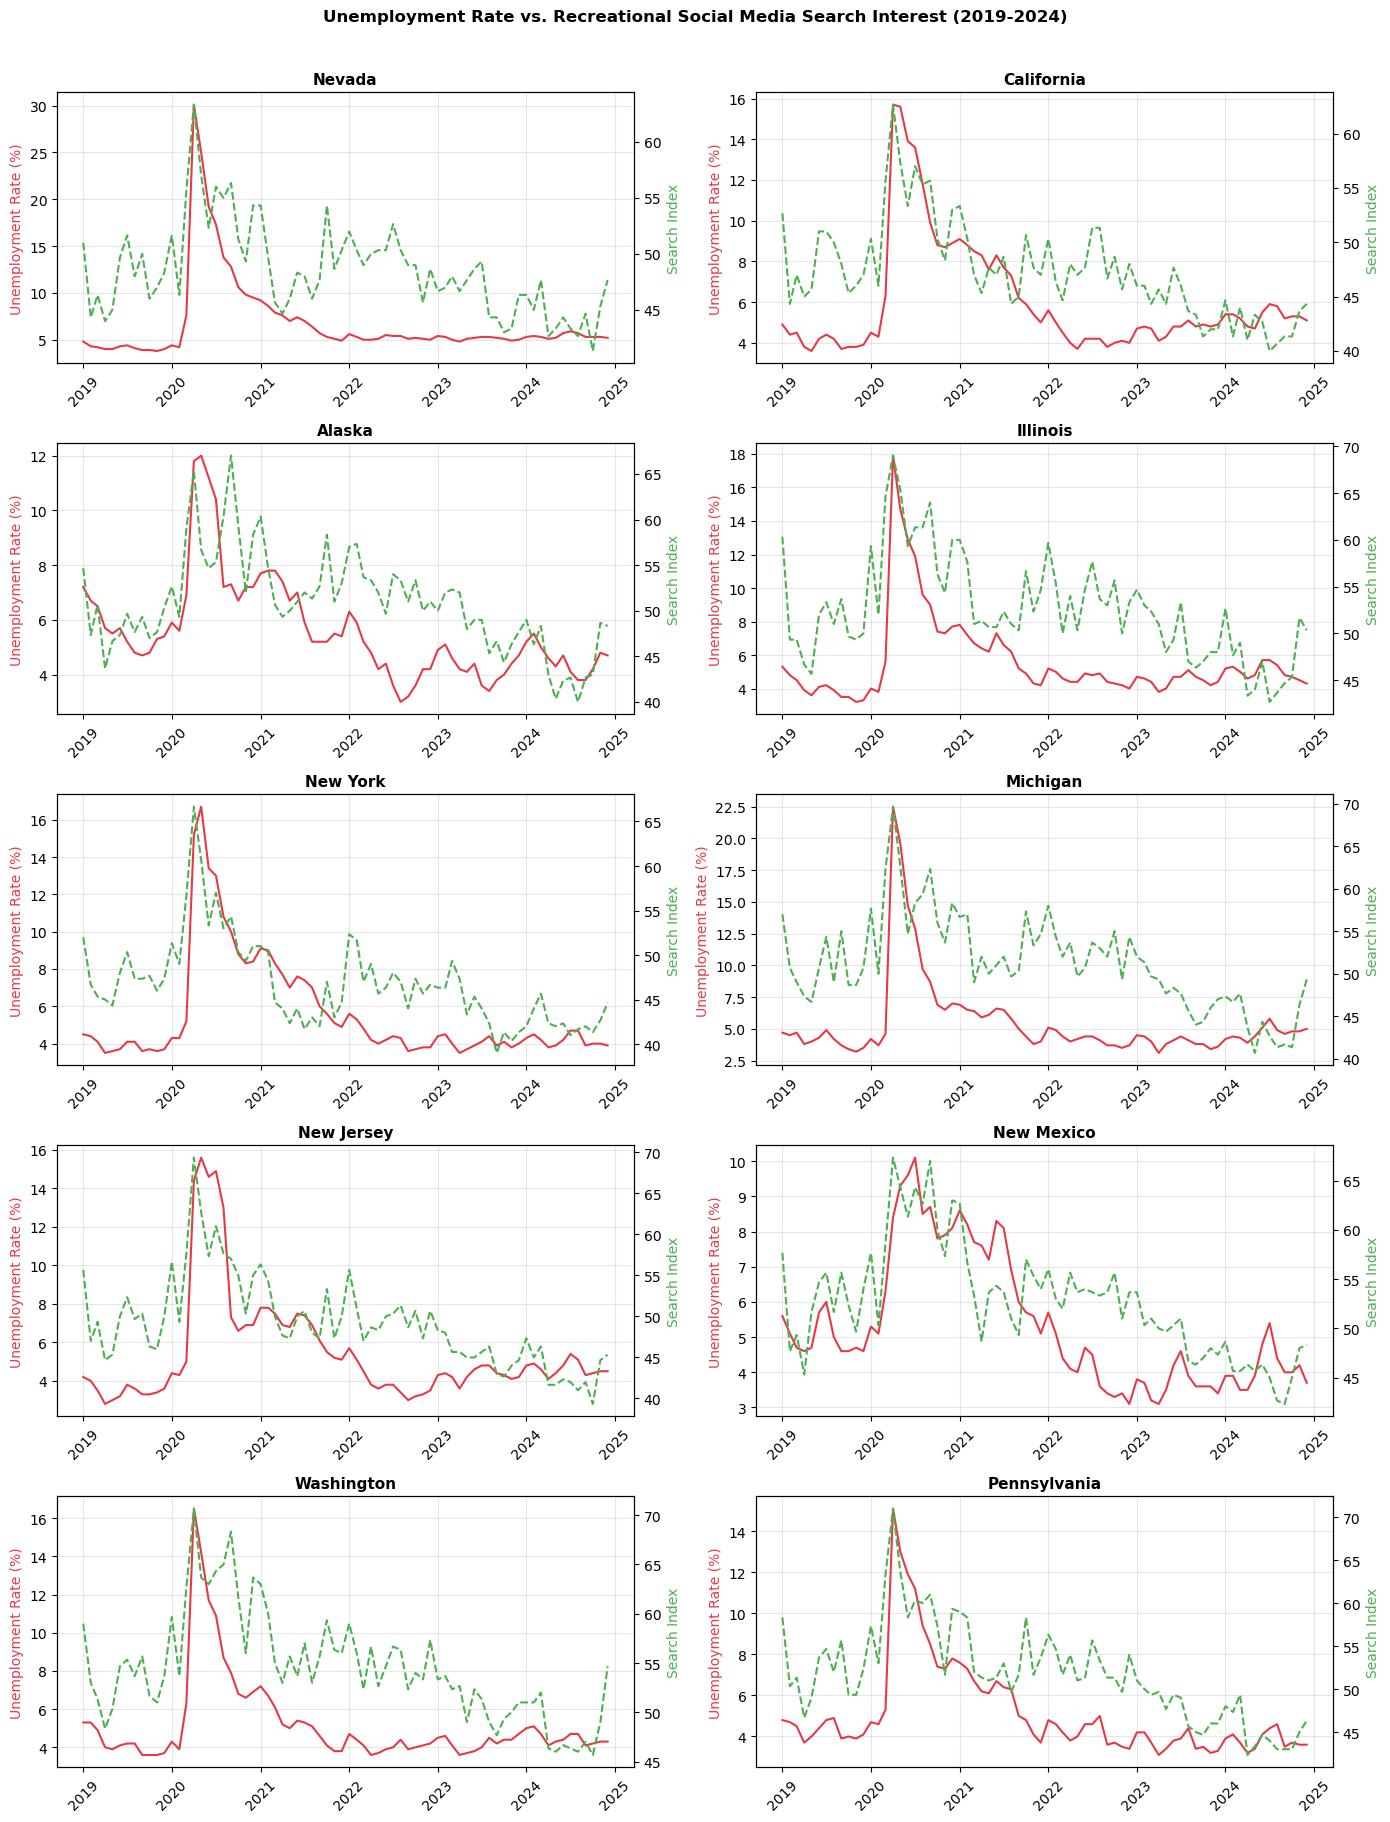

Saved: recreational_trends_comparison.png


In [9]:
if recreational_records:
    plot_trends_comparison(records, recreational_records, top10_states,
                           category="recreational", result_dir=RESULTS_DIR)

Saved: average_trends.png


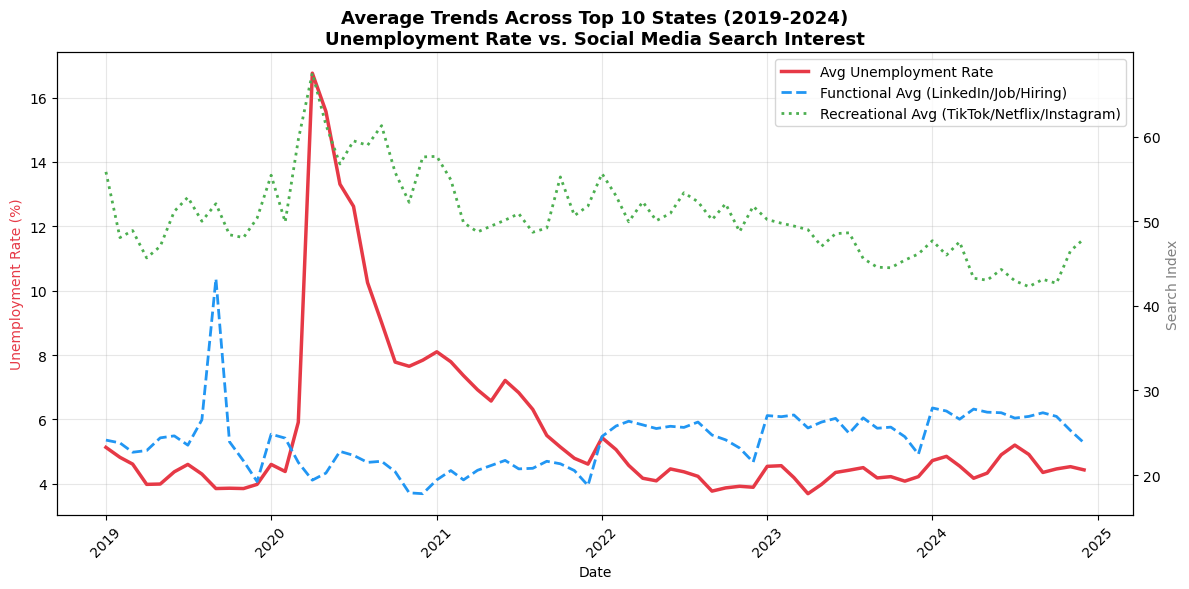

In [10]:
if functional_records and recreational_records:
    plot_average_trends(records, functional_records, recreational_records,
                        top10_states, result_dir=RESULTS_DIR)